In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebranm,./ ytrds -
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/bhavika04/moisesdb/moisesdb/moisesdb_v0.1/04798708-6915-4dbc-842e-d394d545d4eb/data.json
/kaggle/input/datasets/bhavika04/moisesdb/moisesdb/moisesdb_v0.1/04798708-6915-4dbc-842e-d394d545d4eb/other_keys/57f2c1b8-0ebf-46e4-8768-1f99e1c82d58.wav
/kaggle/input/datasets/bhavika04/moisesdb/moisesdb/moisesdb_v0.1/04798708-6915-4dbc-842e-d394d545d4eb/bass/daa4f718-04a0-4fa4-895c-63d5c393d459.wav
/kaggle/input/datasets/bhavika04/moisesdb/moisesdb/moisesdb_v0.1/04798708-6915-4dbc-842e-d394d545d4eb/drums/d9e73db4-ba15-4672-b9c7-425ef1d57f82.wav
/kaggle/input/datasets/bhavika04/moisesdb/moisesdb/moisesdb_v0.1/04798708-6915-4dbc-842e-d394d545d4eb/drums/2d1d1e4b-983d-4d19-886b-64e343639532.wav
/kaggle/input/datasets/bhavika04/moisesdb/moisesdb/moisesdb_v0.1/04798708-6915-4dbc-842e-d394d545d4eb/drums/565bc8dc-2115-4740-af0a-a5fae52542c5.wav
/kaggle/input/datasets/bhavika04/moisesdb/moisesdb/moisesdb_v0.1/04798708-6915-4dbc-842e-d394d545d4eb/guitar/7d65d554-6890-4cfa-bc9a-f35bf4

In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.manifold import TSNE
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


In [3]:
!pip install git+https://github.com/moises-ai/moises-db.git



  Cloning https://github.com/moises-ai/moises-db.git to /tmp/pip-req-build-lg50nuuu
  Running command git clone --filter=blob:none --quiet https://github.com/moises-ai/moises-db.git /tmp/pip-req-build-lg50nuuu
  Resolved https://github.com/moises-ai/moises-db.git to commit 1fbc5c784e24c6f0eb826d7ee782b53a5964b9b6
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 4.6 MB/s eta 0:00:00a 0:00:01
  Created wheel for moises-db: filename=moises_db-0.0.3-py3-none-any.whl size=15696 sha256=00f0e06728de62f5a6c111bb7729c69ceffedb0a74f5e1c4bfa126b3786568bd
  Stored in directory: /tmp/pip-ephem-wheel-cache-kto03gsv/wheels/a6/e3/0d/c12feb835619541bce8f3adafdefe4d437b49691370f8a969a
Successfully built moises-db
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2026.2.0
    Uninstalling fsspec-2026.2.0:
      Successfully uninstalled fsspe

In [4]:
from pathlib import Path
import os
import json
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import torch
import shutil
import time

In [5]:
# Correct path based on your Kaggle dataset structure
DATASET_ROOT = "/kaggle/input/datasets/bhavika04/moisesdb/moisesdb/moisesdb_v0.1"

records = []

for song_dir in sorted(Path(DATASET_ROOT).iterdir()):
    if not song_dir.is_dir():
        continue
    # Each subfolder inside the song dir IS the instrument name
    for instrument_dir in song_dir.iterdir():
        if not instrument_dir.is_dir():
            continue
        label = instrument_dir.name.lower()  # e.g. "drums", "vocals", "guitar"
        for wav_file in instrument_dir.glob("*.wav"):
            records.append({"path": str(wav_file), "label": label})

df_files = pd.DataFrame(records)
print(f"Found {len(df_files)} stem files")
print(f"\nLabel distribution:\n{df_files['label'].value_counts()}")

Found 870 stem files

Label distribution:
label
drums            307
guitar           140
vocals           122
bass              98
other_keys        82
percussion        50
piano             34
other             18
bowed_strings     11
wind               6
other_plucked      2
Name: count, dtype: int64


In [6]:
# Kaggle dataset root
DATASET_ROOT = Path("/kaggle/input/datasets/bhavika04/moisesdb/moisesdb/moisesdb_v0.1")

print(DATASET_ROOT.exists(), DATASET_ROOT)

True /kaggle/input/datasets/bhavika04/moisesdb/moisesdb/moisesdb_v0.1


In [7]:
for dirname, _, filenames in os.walk(DATASET_ROOT):
    for filename in filenames[:5]:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/bhavika04/moisesdb/moisesdb/moisesdb_v0.1/04798708-6915-4dbc-842e-d394d545d4eb/data.json
/kaggle/input/datasets/bhavika04/moisesdb/moisesdb/moisesdb_v0.1/04798708-6915-4dbc-842e-d394d545d4eb/other_keys/57f2c1b8-0ebf-46e4-8768-1f99e1c82d58.wav
/kaggle/input/datasets/bhavika04/moisesdb/moisesdb/moisesdb_v0.1/04798708-6915-4dbc-842e-d394d545d4eb/bass/daa4f718-04a0-4fa4-895c-63d5c393d459.wav
/kaggle/input/datasets/bhavika04/moisesdb/moisesdb/moisesdb_v0.1/04798708-6915-4dbc-842e-d394d545d4eb/drums/d9e73db4-ba15-4672-b9c7-425ef1d57f82.wav
/kaggle/input/datasets/bhavika04/moisesdb/moisesdb/moisesdb_v0.1/04798708-6915-4dbc-842e-d394d545d4eb/drums/2d1d1e4b-983d-4d19-886b-64e343639532.wav
/kaggle/input/datasets/bhavika04/moisesdb/moisesdb/moisesdb_v0.1/04798708-6915-4dbc-842e-d394d545d4eb/drums/565bc8dc-2115-4740-af0a-a5fae52542c5.wav
/kaggle/input/datasets/bhavika04/moisesdb/moisesdb/moisesdb_v0.1/04798708-6915-4dbc-842e-d394d545d4eb/guitar/7d65d554-6890-4cfa-bc9a-f35bf4

In [8]:
records = []

for song_dir in sorted(DATASET_ROOT.iterdir()):
    if not song_dir.is_dir():
        continue

    # optional metadata file
    meta_path = song_dir / "data.json"
    meta = {}
    if meta_path.exists():
        try:
            with open(meta_path, "r", encoding="utf-8") as f:
                meta = json.load(f)
        except Exception:
            meta = {}

    for instrument_dir in song_dir.iterdir():
        if not instrument_dir.is_dir():
            continue

        label = instrument_dir.name.lower()

        for wav_file in instrument_dir.glob("*.wav"):
            records.append({
                "track_id": song_dir.name,
                "label": label,
                "path": str(wav_file),
                "filename": wav_file.name,
                "data_json": str(meta_path) if meta_path.exists() else None,
                "meta": meta
            })

df_files = pd.DataFrame(records)

print(f"Found {len(df_files)} stem files")
df_files.head()

Found 870 stem files


,track_id,label,path,filename,data_json,meta
0,0358fd1e-244a-4422-9a42-29b5d68f6e4b,piano,/kaggle/input/datasets/bhavika04/moisesdb/mois...,c2f9ff20-b8e7-4216-9e5c-a579a739d3a7.wav,/kaggle/input/datasets/bhavika04/moisesdb/mois...,"{'song': 'What Are The Odds', 'artist': 'Frank..."
1,0358fd1e-244a-4422-9a42-29b5d68f6e4b,other_keys,/kaggle/input/datasets/bhavika04/moisesdb/mois...,b5b2143d-8028-4822-bc45-8f5b5cb53909.wav,/kaggle/input/datasets/bhavika04/moisesdb/mois...,"{'song': 'What Are The Odds', 'artist': 'Frank..."
2,0358fd1e-244a-4422-9a42-29b5d68f6e4b,drums,/kaggle/input/datasets/bhavika04/moisesdb/mois...,9da6b01c-86d6-440d-a5cb-4502b469dde0.wav,/kaggle/input/datasets/bhavika04/moisesdb/mois...,"{'song': 'What Are The Odds', 'artist': 'Frank..."
3,0358fd1e-244a-4422-9a42-29b5d68f6e4b,drums,/kaggle/input/datasets/bhavika04/moisesdb/mois...,09d32b5c-7741-4640-8ee5-2b15668751a5.wav,/kaggle/input/datasets/bhavika04/moisesdb/mois...,"{'song': 'What Are The Odds', 'artist': 'Frank..."
4,0358fd1e-244a-4422-9a42-29b5d68f6e4b,guitar,/kaggle/input/datasets/bhavika04/moisesdb/mois...,823ef386-e9f0-4ee4-9bf2-99d82f056bf0.wav,/kaggle/input/datasets/bhavika04/moisesdb/mois...,"{'song': 'What Are The Odds', 'artist': 'Frank..."


In [9]:
n_songs = len(df_files)


In [10]:
print("Label distribution:")
print(df_files["label"].value_counts())

Label distribution:
label
drums            307
guitar           140
vocals           122
bass              98
other_keys        82
percussion        50
piano             34
other             18
bowed_strings     11
wind               6
other_plucked      2
Name: count, dtype: int64


In [11]:
df_tracks = (
    df_files.groupby("track_id")
    .agg(
        n_stems=("label", "count"),
        labels=("label", lambda x: sorted(set(x))),
        n_unique_labels=("label", "nunique")
    )
    .reset_index()
)

print(f"Number of tracks: {len(df_tracks)}")
df_tracks.head()

Number of tracks: 80


,track_id,n_stems,labels,n_unique_labels
0,0358fd1e-244a-4422-9a42-29b5d68f6e4b,8,"[drums, guitar, other_keys, percussion, piano,...",6
1,04204031-4f98-44ba-9c47-98c2f2e6b8fc,9,"[bass, drums, guitar, vocals]",4
2,045dcfd1-e960-4332-80cc-fdacc4a7c6a7,9,"[bass, drums, guitar, vocals]",4
3,046ab651-a333-46e1-9d27-ab14ee036c42,13,"[bass, drums, guitar, other, percussion, vocals]",6
4,04798708-6915-4dbc-842e-d394d545d4eb,8,"[bass, drums, guitar, other_keys, vocals]",5


In [12]:
def get_track_rows(track_id):
    return df_files[df_files["track_id"] == track_id].copy()

def get_track_ids():
    return sorted(df_files["track_id"].unique())

def load_audio(path, sr=44100, mono=False, duration=None, offset=0.0):
    y, sr = librosa.load(path, sr=sr, mono=mono, duration=duration, offset=offset)
    return y, sr

def load_track_stems(track_id, sr=44100, duration=None, offset=0.0, mono=False):
    """
    Returns:
        stems_dict: {label: waveform}
        sr: sample rate
    """
    rows = get_track_rows(track_id)
    stems = {}

    for _, row in rows.iterrows():
        y, sr = load_audio(
            row["path"],
            sr=sr,
            mono=mono,
            duration=duration,
            offset=offset
        )
        stems[row["label"]] = y

    return stems, sr

def build_mixture_from_stems(stems_dict):
    """
    Mimics track.audio by summing the stems.
    Assumes all stems are same length after loading.
    """
    if not stems_dict:
        return None

    arrays = list(stems_dict.values())

    min_len = min(a.shape[-1] for a in arrays)
    arrays = [a[..., :min_len] for a in arrays]

    mixture = np.sum(arrays, axis=0)
    return mixture

def get_track_data(track_id, sr=44100, duration=None, offset=0.0, mono=False):
    """
    Replacement for:
        track = db[i]
        stems = track.stems
        mixture = track.audio
    """
    stems, sr = load_track_stems(
        track_id,
        sr=sr,
        duration=duration,
        offset=offset,
        mono=mono
    )
    mixture = build_mixture_from_stems(stems)
    return {
        "track_id": track_id,
        "stems": stems,
        "audio": mixture,
        "sr": sr
    }

In [13]:
track_ids = get_track_ids()
n_songs = len(track_ids)

print(f"Number of songs/tracks: {n_songs}")

first_track_id = track_ids[0]
track = get_track_data(first_track_id, sr=44100, mono=False)

print("First track id:", first_track_id)
print("Stem labels:", list(track["stems"].keys()))
print("Mixture shape:", track["audio"].shape if track["audio"] is not None else None)

Number of songs/tracks: 80
First track id: 0358fd1e-244a-4422-9a42-29b5d68f6e4b
Stem labels: ['piano', 'other_keys', 'drums', 'guitar', 'percussion', 'vocals']
Mixture shape: (2, 14437244)


In [14]:
track = get_track_data(first_track_id, sr=44100, mono=False)

stems = track["stems"]
mixture = track["audio"]

stems_list = list(stems.keys())
print(stems_list)

['piano', 'other_keys', 'drums', 'guitar', 'percussion', 'vocals']


In [15]:
track_rows = get_track_rows(first_track_id)
track_rows[["label", "path"]]

,label,path
0,piano,/kaggle/input/datasets/bhavika04/moisesdb/mois...
1,other_keys,/kaggle/input/datasets/bhavika04/moisesdb/mois...
2,drums,/kaggle/input/datasets/bhavika04/moisesdb/mois...
3,drums,/kaggle/input/datasets/bhavika04/moisesdb/mois...
4,guitar,/kaggle/input/datasets/bhavika04/moisesdb/mois...
5,guitar,/kaggle/input/datasets/bhavika04/moisesdb/mois...
6,percussion,/kaggle/input/datasets/bhavika04/moisesdb/mois...
7,vocals,/kaggle/input/datasets/bhavika04/moisesdb/mois...


In [16]:
save_dir = Path("/kaggle/working/moises-db-stems") / first_track_id
save_dir.mkdir(parents=True, exist_ok=True)

track_rows = get_track_rows(first_track_id)
for _, row in track_rows.iterrows():
    src = Path(row["path"])
    dst = save_dir / f"{row['label']}_{src.name}"
    shutil.copy(src, dst)

print("Saved stems to:", save_dir)
print(list(save_dir.iterdir()))

Saved stems to: /kaggle/working/moises-db-stems/0358fd1e-244a-4422-9a42-29b5d68f6e4b
[PosixPath('/kaggle/working/moises-db-stems/0358fd1e-244a-4422-9a42-29b5d68f6e4b/other_keys_b5b2143d-8028-4822-bc45-8f5b5cb53909.wav'), PosixPath('/kaggle/working/moises-db-stems/0358fd1e-244a-4422-9a42-29b5d68f6e4b/drums_9da6b01c-86d6-440d-a5cb-4502b469dde0.wav'), PosixPath('/kaggle/working/moises-db-stems/0358fd1e-244a-4422-9a42-29b5d68f6e4b/percussion_9fb19e6b-4e0d-4c32-a4df-00f46e6ad4e9.wav'), PosixPath('/kaggle/working/moises-db-stems/0358fd1e-244a-4422-9a42-29b5d68f6e4b/drums_09d32b5c-7741-4640-8ee5-2b15668751a5.wav'), PosixPath('/kaggle/working/moises-db-stems/0358fd1e-244a-4422-9a42-29b5d68f6e4b/vocals_fc65a9d8-8365-4e8b-b706-cd160a2e956d.wav'), PosixPath('/kaggle/working/moises-db-stems/0358fd1e-244a-4422-9a42-29b5d68f6e4b/piano_c2f9ff20-b8e7-4216-9e5c-a579a739d3a7.wav'), PosixPath('/kaggle/working/moises-db-stems/0358fd1e-244a-4422-9a42-29b5d68f6e4b/guitar_823ef386-e9f0-4ee4-9bf2-99d82f056bf0

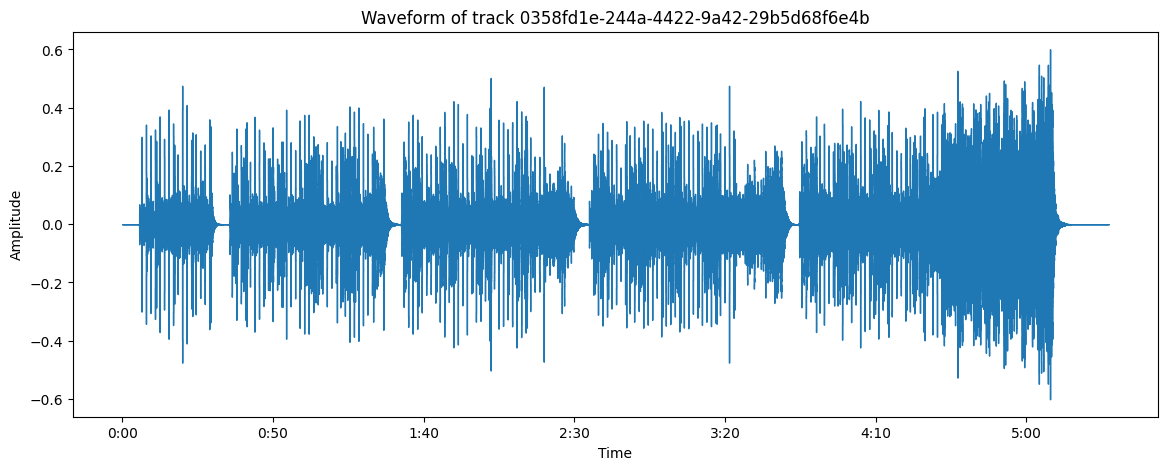

In [17]:
track = get_track_data(first_track_id, sr=44100, mono=True)
audio_data = track["audio"]
sr = track["sr"]

plt.figure(figsize=(14, 5))
librosa.display.waveshow(audio_data, sr=sr)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title(f"Waveform of track {first_track_id}")
plt.show()

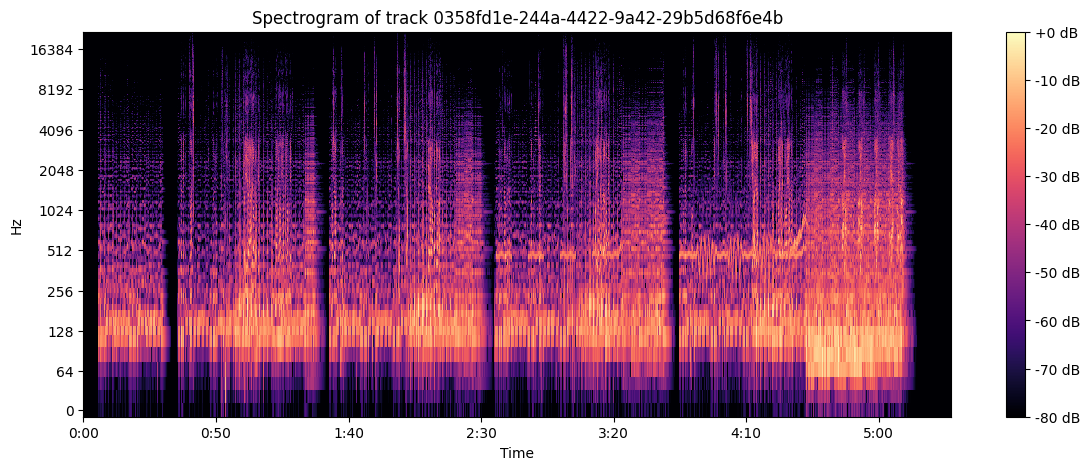

In [18]:
track = get_track_data(first_track_id, sr=44100, mono=True)
audio_data = track["audio"]
sr = track["sr"]

S = np.abs(librosa.stft(audio_data, n_fft=2048, hop_length=512))
S_db = librosa.amplitude_to_db(S, ref=np.max)

plt.figure(figsize=(14, 5))
librosa.display.specshow(S_db, sr=sr, hop_length=512, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Spectrogram of track {first_track_id}")
plt.show()

In [19]:
df_instruments = df_files[["track_id", "label"]].rename(columns={"label": "Instrument Name"})
print(df_instruments.head())

                               track_id Instrument Name
0  0358fd1e-244a-4422-9a42-29b5d68f6e4b           piano
1  0358fd1e-244a-4422-9a42-29b5d68f6e4b      other_keys
2  0358fd1e-244a-4422-9a42-29b5d68f6e4b           drums
3  0358fd1e-244a-4422-9a42-29b5d68f6e4b           drums
4  0358fd1e-244a-4422-9a42-29b5d68f6e4b          guitar


In [20]:
file_path = "/kaggle/working/output.csv"
df_instruments.to_csv(file_path, index=False)
print("Saved:", file_path)

Saved: /kaggle/working/output.csv


In [21]:
print("Unique instruments:", df_instruments["Instrument Name"].nunique())
print(df_instruments["Instrument Name"].value_counts())

Unique instruments: 11
Instrument Name
drums            307
guitar           140
vocals           122
bass              98
other_keys        82
percussion        50
piano             34
other             18
bowed_strings     11
wind               6
other_plucked      2
Name: count, dtype: int64


In [22]:
new_df = (
    df_files.groupby("track_id")
    .size()
    .reset_index(name="Number of Stems")
    .rename(columns={"track_id": "Track Name"})
)

print(new_df.head())

                             Track Name  Number of Stems
0  0358fd1e-244a-4422-9a42-29b5d68f6e4b                8
1  04204031-4f98-44ba-9c47-98c2f2e6b8fc                9
2  045dcfd1-e960-4332-80cc-fdacc4a7c6a7                9
3  046ab651-a333-46e1-9d27-ab14ee036c42               13
4  04798708-6915-4dbc-842e-d394d545d4eb                8


In [23]:
print(new_df["Number of Stems"].value_counts())

Number of Stems
9     16
8     11
13     7
7      7
12     7
14     6
11     5
10     5
17     5
15     5
4      2
16     2
6      1
19     1
Name: count, dtype: int64


In [24]:
file_path_new = "/kaggle/working/output_stem_count.csv"
new_df.to_csv(file_path_new, index=False)
print("Saved:", file_path_new)

Saved: /kaggle/working/output_stem_count.csv


In [25]:
def input_audio_to_spectrogram(audio_data, sr=16000, n_fft=2048, hop_length=512):
    mono_signal = np.array(audio_data, dtype=np.float32)

    if mono_signal.ndim == 2:
        mono_signal = np.mean(mono_signal, axis=0)

    mono_signal = np.nan_to_num(mono_signal, nan=0.0, posinf=0.0, neginf=0.0)

    if len(mono_signal) == 0 or np.max(np.abs(mono_signal)) < 1e-8:
        return None, None, None

    eps = 1e-10
    spectrogram = np.abs(librosa.stft(mono_signal, n_fft=n_fft, hop_length=hop_length))
    log_spectrogram = librosa.amplitude_to_db(np.maximum(spectrogram, eps), ref=np.max)

    denom = log_spectrogram.max() - log_spectrogram.min()
    if denom < eps:
        normalized_spectrogram = np.zeros_like(log_spectrogram, dtype=np.float32)
    else:
        normalized_spectrogram = (log_spectrogram - log_spectrogram.min()) / (denom + eps)

    tensor_spectrogram = torch.tensor(normalized_spectrogram, dtype=torch.float32)

    return spectrogram, log_spectrogram, tensor_spectrogram

In [26]:
def adjust_shape_y(y_spectrogram, x_spectrogram):
    target_frames = x_spectrogram.shape[1]
    current_frames = y_spectrogram.shape[1]

    if current_frames >= target_frames:
        return y_spectrogram[:, :target_frames]

    extra_frames = target_frames - current_frames
    zeros_array = np.zeros((y_spectrogram.shape[0], extra_frames), dtype=y_spectrogram.dtype)
    padded_y = np.hstack((y_spectrogram, zeros_array))
    return padded_y

In [27]:
from pathlib import Path
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    adjusted_rand_score,
    normalized_mutual_info_score
)
from sklearn.manifold import TSNE

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [28]:
def load_audio_file(path, sr=16000, mono=False):
    y, sr = librosa.load(path, sr=sr, mono=mono)
    y = np.asarray(y, dtype=np.float32)
    y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)
    return y, sr

In [29]:
def extract_features_from_audio(audio_data, sr=44100):
    feature_dict = {}

    mono_signal = np.array(audio_data, dtype=np.float32)

    if mono_signal.ndim == 2:
        mono_signal = np.mean(mono_signal, axis=0)

    mono_signal = np.nan_to_num(mono_signal, nan=0.0, posinf=0.0, neginf=0.0)

    # skip silent / broken signals
    if len(mono_signal) == 0 or np.max(np.abs(mono_signal)) < 1e-8:
        return None, None, None

    # basic features
    rms = librosa.feature.rms(y=mono_signal)[0]
    zcr = librosa.feature.zero_crossing_rate(mono_signal)[0]
    spectral_centroid = librosa.feature.spectral_centroid(y=mono_signal, sr=sr)[0]

    feature_dict["rms_mean"] = np.mean(rms)
    feature_dict["rms_std"] = np.std(rms)

    feature_dict["zcr_mean"] = np.mean(zcr)
    feature_dict["zcr_std"] = np.std(zcr)

    feature_dict["spectral_centroid_mean"] = np.mean(spectral_centroid)
    feature_dict["spectral_centroid_std"] = np.std(spectral_centroid)

    spectrogram, log_spectrogram, tensor_spectrogram = input_audio_to_spectrogram(audio_data, sr=sr)

    if spectrogram is None or np.max(spectrogram) < 1e-8:
        return None, None, None

    feature_dict["spec_mean"] = np.mean(log_spectrogram)
    feature_dict["spec_std"] = np.std(log_spectrogram)
    feature_dict["spec_max"] = np.max(log_spectrogram)
    feature_dict["spec_min"] = np.min(log_spectrogram)

    chroma = librosa.feature.chroma_stft(S=spectrogram, sr=16000)
    for i in range(chroma.shape[0]):
        feature_dict[f"chroma_{i}_mean"] = np.mean(chroma[i])
        feature_dict[f"chroma_{i}_std"] = np.std(chroma[i])

    mfcc = librosa.feature.mfcc(y=mono_signal, sr=sr, n_mfcc=13)
    for i in range(mfcc.shape[0]):
        feature_dict[f"mfcc_{i}_mean"] = np.mean(mfcc[i])
        feature_dict[f"mfcc_{i}_std"] = np.std(mfcc[i])

    return feature_dict, spectrogram, tensor_spectrogram

In [30]:
sample_row = df_files.iloc[0]

print("label:", sample_row["label"])
print("path:", sample_row["path"])

audio_data, sr = load_audio_file(sample_row["path"], sr=16000, mono=False)

print("Loaded sr:", sr)
print("audio shape:", audio_data.shape)
print("audio dtype:", audio_data.dtype)
print("audio min:", np.min(audio_data))
print("audio max:", np.max(audio_data))
print("mean abs:", np.mean(np.abs(audio_data)))
print("is all zero:", np.all(audio_data == 0))

label: piano
path: /kaggle/input/datasets/bhavika04/moisesdb/moisesdb/moisesdb_v0.1/0358fd1e-244a-4422-9a42-29b5d68f6e4b/piano/c2f9ff20-b8e7-4216-9e5c-a579a739d3a7.wav
Loaded sr: 16000
audio shape: (2, 5238003)
audio dtype: float32
audio min: -0.15317187
audio max: 0.1788783
mean abs: 0.005105645
is all zero: False


In [31]:
usable_index = None

for i, row in df_files.iterrows():
    try:
        y, sr = load_audio_file(row["path"], sr=16000, mono=False)

        if y.ndim == 2:
            y_check = np.mean(y, axis=0)
        else:
            y_check = y

        mean_abs = np.mean(np.abs(y_check))
        max_abs = np.max(np.abs(y_check))

        if max_abs > 1e-4 and mean_abs > 1e-5:
            usable_index = i
            print("Found usable file")
            print("index:", i)
            print("label:", row["label"])
            print("path:", row["path"])
            print("mean abs:", mean_abs)
            print("max abs:", max_abs)
            break
    except Exception as e:
        continue

print("usable_index:", usable_index)

Found usable file
index: 0
label: piano
path: /kaggle/input/datasets/bhavika04/moisesdb/moisesdb/moisesdb_v0.1/0358fd1e-244a-4422-9a42-29b5d68f6e4b/piano/c2f9ff20-b8e7-4216-9e5c-a579a739d3a7.wav
mean abs: 0.0043365415
max abs: 0.1490054
usable_index: 0


Spectrogram shape: (1025, 10231)
Log spectrogram shape: (1025, 10231)
Tensor spectrogram shape: torch.Size([1025, 10231])


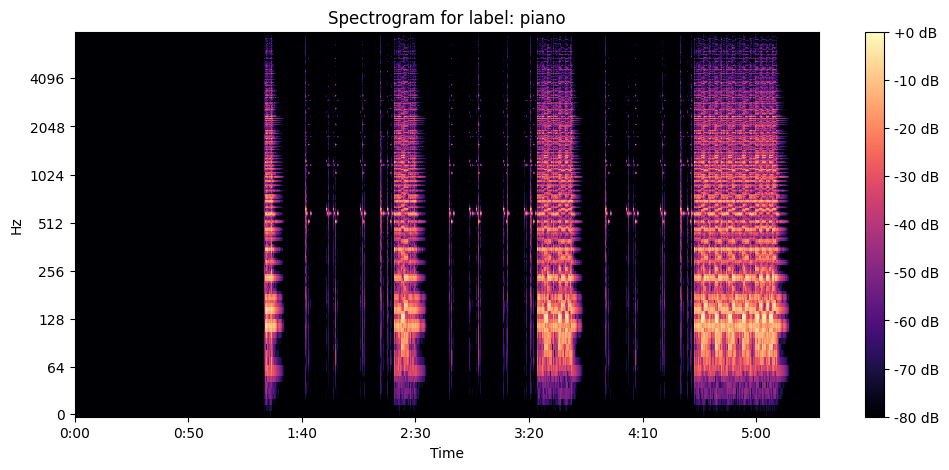

In [32]:
sample_row = df_files.iloc[usable_index]

audio_data, sr = load_audio_file(sample_row["path"], sr=16000, mono=False)
spectrogram, log_spectrogram, tensor_spectrogram = input_audio_to_spectrogram(audio_data, sr=sr)

print("Spectrogram shape:", None if spectrogram is None else spectrogram.shape)
print("Log spectrogram shape:", None if log_spectrogram is None else log_spectrogram.shape)
print("Tensor spectrogram shape:", None if tensor_spectrogram is None else tensor_spectrogram.shape)

plt.figure(figsize=(12, 5))
librosa.display.specshow(
    log_spectrogram,
    sr=sr,
    hop_length=512,
    x_axis='time',
    y_axis='log'
)
plt.colorbar(format='%+2.0f dB')
plt.title(f"Spectrogram for label: {sample_row['label']}")
plt.show()

In [33]:
def extract_features_from_audio(audio_data, sr=16000):
    feature_dict = {}

    mono_signal = np.array(audio_data, dtype=np.float32)

    if mono_signal.ndim == 2:
        mono_signal = np.mean(mono_signal, axis=0)

    mono_signal = np.nan_to_num(mono_signal, nan=0.0, posinf=0.0, neginf=0.0)

    if len(mono_signal) == 0 or np.max(np.abs(mono_signal)) < 1e-8:
        return None, None, None

    rms = librosa.feature.rms(y=mono_signal)[0]
    zcr = librosa.feature.zero_crossing_rate(mono_signal)[0]
    spectral_centroid = librosa.feature.spectral_centroid(y=mono_signal, sr=sr)[0]

    feature_dict["rms_mean"] = np.mean(rms)
    feature_dict["rms_std"] = np.std(rms)

    feature_dict["zcr_mean"] = np.mean(zcr)
    feature_dict["zcr_std"] = np.std(zcr)

    feature_dict["spectral_centroid_mean"] = np.mean(spectral_centroid)
    feature_dict["spectral_centroid_std"] = np.std(spectral_centroid)

    spectrogram, log_spectrogram, tensor_spectrogram = input_audio_to_spectrogram(audio_data, sr=sr)

    if spectrogram is None:
        return None, None, None

    feature_dict["spec_mean"] = np.mean(log_spectrogram)
    feature_dict["spec_std"] = np.std(log_spectrogram)
    feature_dict["spec_max"] = np.max(log_spectrogram)
    feature_dict["spec_min"] = np.min(log_spectrogram)

    chroma = librosa.feature.chroma_stft(S=spectrogram, sr=sr)
    for i in range(chroma.shape[0]):
        feature_dict[f"chroma_{i}_mean"] = np.mean(chroma[i])
        feature_dict[f"chroma_{i}_std"] = np.std(chroma[i])

    mfcc = librosa.feature.mfcc(y=mono_signal, sr=sr, n_mfcc=13)
    for i in range(mfcc.shape[0]):
        feature_dict[f"mfcc_{i}_mean"] = np.mean(mfcc[i])
        feature_dict[f"mfcc_{i}_std"] = np.std(mfcc[i])

    return feature_dict, spectrogram, tensor_spectrogram

In [34]:
sample_row = df_files.iloc[usable_index]
audio_data, sr = load_audio_file(sample_row["path"], sr=16000, mono=False)

feature_dict, spectrogram, tensor_spectrogram = extract_features_from_audio(audio_data, sr=sr)

print("Number of extracted features:", len(feature_dict))
print("Some feature names:", list(feature_dict.keys())[:10])

Number of extracted features: 60
Some feature names: ['rms_mean', 'rms_std', 'zcr_mean', 'zcr_std', 'spectral_centroid_mean', 'spectral_centroid_std', 'spec_mean', 'spec_std', 'spec_max', 'spec_min']


In [ ]:
feature_rows = []

start_time = time.time()

for idx, row in df_files.iterrows():
    try:
        audio_data, sr = load_audio_file(row["path"], sr=16000, mono=False)

        feature_dict, spectrogram, tensor_spectrogram = extract_features_from_audio(audio_data, sr=sr)

        if feature_dict is None:
            print(f"Skipping silent/bad file: {row['path']}")
            continue

        final_row = {
            "track_id": row["track_id"],
            "label": row["label"],
            "path": row["path"]
        }
        final_row.update(feature_dict)

        feature_rows.append(final_row)

        if idx % 100 == 0:
            print(f"Processed {idx} / {len(df_files)}")

    except Exception as e:
        print(f"Skipping {row['path']} because of error: {e}")

end_time = time.time()

df_features = pd.DataFrame(feature_rows)

print("Feature extraction complete")
print("Shape:", df_features.shape)
print(f"Execution time: {end_time - start_time:.4f} seconds")
df_features.head()

Processed 0 / 870
Processed 100 / 870
Processed 200 / 870
Processed 300 / 870
Processed 500 / 870
Processed 600 / 870
Processed 700 / 870


In [ ]:
df_features.to_csv("/kaggle/working/df_features.csv", index=False)
print("Saved to /kaggle/working/df_features.csv")

In [ ]:
label_counts = df_features["label"].value_counts()
valid_labels = label_counts[label_counts >= 5].index

df_features = df_features[df_features["label"].isin(valid_labels)].reset_index(drop=True)

print(df_features["label"].value_counts())

In [ ]:
meta_cols = ["track_id", "label", "path"]
feature_cols = [col for col in df_features.columns if col not in meta_cols]

X = df_features[feature_cols].values
y = df_features["label"].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("X shape:", X.shape)
print("y shape:", y_encoded.shape)
print("Classes:", list(label_encoder.classes_))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

In [ ]:
def plot_confusion_matrix_custom(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()

In [ ]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", C=10, gamma="scale"))
])

svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

svm_acc = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_acc)
print(classification_report(y_test, y_pred_svm, target_names=label_encoder.classes_))

In [ ]:
plot_confusion_matrix_custom(
    y_test,
    y_pred_svm,
    class_names=label_encoder.classes_,
    title="SVM Confusion Matrix"
)

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_acc)
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

kmeans_model = KMeans(
    n_clusters=len(label_encoder.classes_),
    random_state=42,
    n_init=20
)

kmeans_model.fit(X_train_scaled)
y_pred_kmeans = kmeans_model.predict(X_test_scaled)

ari_score = adjusted_rand_score(y_test, y_pred_kmeans)
nmi_score = normalized_mutual_info_score(y_test, y_pred_kmeans)

print("KMeans ARI:", ari_score)
print("KMeans NMI:", nmi_score)

In [ ]:
sample_size = min(2000, len(X_test_scaled))
sample_indices = np.random.choice(len(X_test_scaled), sample_size, replace=False)

X_tsne = X_test_scaled[sample_indices]
y_tsne_true = y_test[sample_indices]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_embedded = tsne.fit_transform(X_tsne)

plt.figure(figsize=(10, 8))
for class_id in np.unique(y_tsne_true):
    mask = y_tsne_true == class_id
    plt.scatter(
        X_embedded[mask, 0],
        X_embedded[mask, 1],
        label=label_encoder.inverse_transform([class_id])[0],
        alpha=0.7
    )

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("t-SNE of Features (True Labels)")
plt.show()

In [ ]:
y_tsne_pred_svm = y_pred_svm[sample_indices]

plt.figure(figsize=(10, 8))
for class_id in np.unique(y_tsne_pred_svm):
    mask = y_tsne_pred_svm == class_id
    plt.scatter(
        X_embedded[mask, 0],
        X_embedded[mask, 1],
        label=label_encoder.inverse_transform([class_id])[0],
        alpha=0.7
    )

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("t-SNE of Features (SVM Predicted Labels)")
plt.show()

In [ ]:
nn_scaler = StandardScaler()
X_train_nn = nn_scaler.fit_transform(X_train)
X_test_nn = nn_scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_nn, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_nn, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [ ]:
class InstrumentFeatureDataset(Dataset):
    def __init__(self, X_tensor, y_tensor):
        self.X = X_tensor
        self.y = y_tensor

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
train_dataset = InstrumentFeatureDataset(X_train_tensor, y_train_tensor)
test_dataset = InstrumentFeatureDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(MLPClassifier, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

mlp_model = MLPClassifier(
    input_dim=X_train_tensor.shape[1],
    num_classes=len(label_encoder.classes_)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)

In [ ]:
num_epochs = 20

for epoch in range(num_epochs):
    mlp_model.train()
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        outputs = mlp_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss / len(train_loader):.4f}")

In [ ]:
mlp_model.eval()
y_pred_mlp = []
y_true_mlp = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = mlp_model(batch_X)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        y_pred_mlp.extend(preds)
        y_true_mlp.extend(batch_y.numpy())

y_pred_mlp = np.array(y_pred_mlp)
y_true_mlp = np.array(y_true_mlp)

mlp_acc = accuracy_score(y_true_mlp, y_pred_mlp)

print("MLP Accuracy:", mlp_acc)
print(classification_report(y_true_mlp, y_pred_mlp, target_names=label_encoder.classes_))

In [ ]:
plot_confusion_matrix_custom(
    y_true_mlp,
    y_pred_mlp,
    class_names=label_encoder.classes_,
    title="MLP Confusion Matrix"
)

In [ ]:
comparison_df = pd.DataFrame([
    {"Model": "SVM", "Metric": "Accuracy", "Score": svm_acc},
    {"Model": "Random Forest", "Metric": "Accuracy", "Score": rf_acc},
    {"Model": "MLP", "Metric": "Accuracy", "Score": mlp_acc},
    {"Model": "KMeans", "Metric": "ARI", "Score": ari_score},
    {"Model": "KMeans", "Metric": "NMI", "Score": nmi_score},
])

comparison_df

In [ ]:
comparison_df.sort_values(by="Score", ascending=False)

In [ ]:
N_MELS = 128
MAX_FRAMES = 400

def extract_logmel(path, sr=22050, n_mels=128, max_frames=400, duration=60):
    try:
        y, _ = librosa.load(path, sr=sr, mono=True, duration=duration)
        y = np.asarray(y, dtype=np.float32)
        y = np.nan_to_num(y)

        if len(y) < sr or np.max(np.abs(y)) < 1e-6:
            return None

        mel = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=n_mels, n_fft=2048, hop_length=512
        )
        logmel = librosa.power_to_db(mel + 1e-10, ref=np.max)

        logmel = (logmel - logmel.mean()) / (logmel.std() + 1e-8)

        if logmel.shape[1] < max_frames:
            pad_width = max_frames - logmel.shape[1]
            logmel = np.pad(logmel, ((0, 0), (0, pad_width)), mode='constant')
        else:
            logmel = logmel[:, :max_frames]

        return logmel.astype(np.float32)

    except Exception:
        return None

In [ ]:
specs = []
spec_labels = []

for i, row in df_filtered.iterrows():
    if i % 50 == 0:
        print(f"Processing {i}/{len(df_filtered)}...")
    s = extract_logmel(row["path"])
    if s is not None:
        specs.append(s)
        spec_labels.append(row["label"])

X_spec = np.array(specs)          # (N, n_mels, frames)
y_spec_raw = np.array(spec_labels)

print("Spectrogram tensor shape:", X_spec.shape)
print("Labels shape:", y_spec_raw.shape)

In [ ]:
le_spec = LabelEncoder()
y_spec = le_spec.fit_transform(y_spec_raw)

X_train_spec, X_test_spec, y_train_spec, y_test_spec = train_test_split(
    X_spec, y_spec, test_size=0.2, random_state=42, stratify=y_spec
)

print(X_train_spec.shape, X_test_spec.shape)
print(list(le_spec.classes_))

In [ ]:
class SpectrogramDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (N,1,M,T)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

In [ ]:
train_loader_spec = DataLoader(SpectrogramDataset(X_train_spec, y_train_spec), batch_size=16, shuffle=True)
test_loader_spec  = DataLoader(SpectrogramDataset(X_test_spec, y_test_spec), batch_size=16, shuffle=False)

In [ ]:
class CNNInstrumentClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model = CNNInstrumentClassifier(num_classes=len(le_spec.classes_)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.5)

print("Device:", device)
print("Parameters:", sum(p.numel() for p in cnn_model.parameters()))

In [ ]:
EPOCHS = 30
cnn_train_losses = []
cnn_train_accs = []

for epoch in range(EPOCHS):
    cnn_model.train()
    total_loss, correct, total = 0.0, 0, 0

    for xb, yb in train_loader_spec:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        out = cnn_model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(yb)
        correct += (out.argmax(1) == yb).sum().item()
        total += len(yb)

    scheduler.step()

    epoch_loss = total_loss / total
    epoch_acc = correct / total

    cnn_train_losses.append(epoch_loss)
    cnn_train_accs.append(epoch_acc)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

In [ ]:
cnn_model.eval()
cnn_preds = []

with torch.no_grad():
    for xb, yb in test_loader_spec:
        xb = xb.to(device)
        preds = cnn_model(xb).argmax(1).cpu().numpy()
        cnn_preds.extend(preds)

cnn_preds = np.array(cnn_preds)
cnn_acc = accuracy_score(y_test_spec, cnn_preds)

print(f"CNN Test Accuracy: {cnn_acc:.4f}")
print(classification_report(y_test_spec, cnn_preds, target_names=le_spec.classes_))

In [ ]:
cm = confusion_matrix(y_test_spec, cnn_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le_spec.classes_, yticklabels=le_spec.classes_)
plt.title(f'CNN Confusion Matrix (Acc = {cnn_acc:.3f})')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

In [ ]:
le_spec = LabelEncoder()
y_spec = le_spec.fit_transform(y_spec_raw)

X_train_spec, X_test_spec, y_train_spec, y_test_spec = train_test_split(
    X_spec, y_spec, test_size=0.2, random_state=42, stratify=y_spec
)

print("Train:", X_train_spec.shape)
print("Test :", X_test_spec.shape)
print("Classes:", list(le_spec.classes_))

In [ ]:
class SpectrogramDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (N,1,M,T)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader_spec = DataLoader(
    SpectrogramDataset(X_train_spec, y_train_spec),
    batch_size=16,
    shuffle=True
)

test_loader_spec = DataLoader(
    SpectrogramDataset(X_test_spec, y_test_spec),
    batch_size=16,
    shuffle=False
)

In [ ]:
class CRNNClassifier(nn.Module):
    def __init__(self, num_classes, n_mels=N_MELS):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2, 2))
        )

        # after 3 pools on mel dim: 128 -> 64 -> 32 -> 16
        self.feature_dim = 64 * (n_mels // 8)

        self.rnn = nn.GRU(
            input_size=self.feature_dim,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: (B,1,M,T)
        x = self.cnn(x)                  # (B,C,M',T')
        x = x.permute(0, 3, 1, 2)        # (B,T',C,M')
        B, T, C, M = x.shape
        x = x.reshape(B, T, C * M)       # (B,T',feature_dim)

        x, _ = self.rnn(x)               # (B,T',2H)
        x = x.mean(dim=1)                # temporal average pooling
        x = self.classifier(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

crnn_model = CRNNClassifier(num_classes=len(le_spec.classes_)).to(device)

print("Training on:", device)
print("Parameters:", sum(p.numel() for p in crnn_model.parameters()))

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(crnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.5)

In [ ]:
EPOCHS = 25
crnn_train_losses = []
crnn_train_accs = []

for epoch in range(EPOCHS):
    crnn_model.train()
    total_loss, correct, total = 0.0, 0, 0

    for xb, yb in train_loader_spec:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        out = crnn_model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(yb)
        correct += (out.argmax(1) == yb).sum().item()
        total += len(yb)

    scheduler.step()

    epoch_loss = total_loss / total
    epoch_acc = correct / total

    crnn_train_losses.append(epoch_loss)
    crnn_train_accs.append(epoch_acc)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

In [ ]:
crnn_model.eval()
crnn_preds = []

with torch.no_grad():
    for xb, yb in test_loader_spec:
        xb = xb.to(device)
        preds = crnn_model(xb).argmax(1).cpu().numpy()
        crnn_preds.extend(preds)

crnn_preds = np.array(crnn_preds)
crnn_acc = accuracy_score(y_test_spec, crnn_preds)

print(f"CRNN Test Accuracy: {crnn_acc:.4f}")
print(classification_report(y_test_spec, crnn_preds, target_names=le_spec.classes_))

In [ ]:
cm = confusion_matrix(y_test_spec, crnn_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=le_spec.classes_,
    yticklabels=le_spec.classes_
)
plt.title(f'CRNN Confusion Matrix (Acc = {crnn_acc:.3f})')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

In [ ]:
comparison_extra_df = pd.DataFrame([
    {"Model": "Random Forest", "Score": rf_acc},
    {"Model": "SVM", "Score": svm_acc},
    {"Model": "MLP", "Score": mlp_acc},
    {"Model": "CNN", "Score": cnn_acc},
    {"Model": "CRNN", "Score": crnn_acc},
])

comparison_extra_df.sort_values("Score", ascending=False)

In [ ]:
SEP_SR = 16000
N_FFT = 1024
HOP = 256
WIN = 1024
MAX_LEN = 256   # time frames after crop/pad
N_FREQ = N_FFT // 2 + 1

def audio_to_magphase(y, n_fft=N_FFT, hop_length=HOP, win_length=WIN):
    stft = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, win_length=win_length)
    mag = np.abs(stft)
    phase = np.angle(stft)
    return mag, phase

def pad_or_crop_spec(spec, max_len=MAX_LEN):
    # spec: (F, T)
    if spec.shape[1] < max_len:
        pad = max_len - spec.shape[1]
        spec = np.pad(spec, ((0,0), (0,pad)), mode='constant')
    else:
        spec = spec[:, :max_len]
    return spec

In [ ]:
TARGET_SOURCES = ["vocals", "drums", "bass", "other"]

class SourceSeparationDataset(Dataset):
    def __init__(self, examples, sr=SEP_SR, max_len=MAX_LEN):
        self.examples = examples
        self.sr = sr
        self.max_len = max_len

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]

        mix_y, _ = librosa.load(ex["mix_path"], sr=self.sr, mono=True)
        mix_mag, _ = audio_to_magphase(mix_y)
        mix_mag = pad_or_crop_spec(mix_mag, self.max_len)

        target_mags = []
        target_masks = []

        eps = 1e-8
        for src in TARGET_SOURCES:
            y, _ = librosa.load(ex["target_paths"][src], sr=self.sr, mono=True)
            src_mag, _ = audio_to_magphase(y)
            src_mag = pad_or_crop_spec(src_mag, self.max_len)

            mask = np.clip(src_mag / (mix_mag + eps), 0.0, 1.0)

            target_mags.append(src_mag.astype(np.float32))
            target_masks.append(mask.astype(np.float32))

        mix_log = np.log1p(mix_mag).astype(np.float32)

        return (
            torch.tensor(mix_log).unsqueeze(0),               # (1,F,T)
            torch.tensor(np.stack(target_masks, axis=0)),     # (K,F,T)
            torch.tensor(np.stack(target_mags, axis=0)),      # (K,F,T)
            torch.tensor(mix_mag.astype(np.float32))          # (F,T)
        )

In [ ]:

SR = 22050
DURATION = 5
N_MFCC = 20
MIN_SAMPLES = 15

label_counts = df_files['label'].value_counts()
valid_labels = label_counts[label_counts >= MIN_SAMPLES].index.tolist()
df_filtered = df_files[df_files['label'].isin(valid_labels)].reset_index(drop=True)
print(f"Keeping {len(valid_labels)} classes, {len(df_filtered)} files")
print("Classes:", valid_labels)

def extract_features(path, sr=SR, duration=DURATION):
    try:
        y, _ = librosa.load(path, sr=sr, duration=duration, mono=True)
        if len(y) < sr:
            return None
        mfcc    = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
        chroma  = librosa.feature.chroma_stft(y=y, sr=sr)
        sc      = librosa.feature.spectral_centroid(y=y, sr=sr)
        zcr     = librosa.feature.zero_crossing_rate(y)
        rms     = librosa.feature.rms(y=y)
        rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        return np.concatenate([
            mfcc.mean(axis=1), mfcc.std(axis=1),
            chroma.mean(axis=1), chroma.std(axis=1),
            sc.mean(axis=1), sc.std(axis=1),
            zcr.mean(axis=1), zcr.std(axis=1),
            rms.mean(axis=1), rms.std(axis=1),
            rolloff.mean(axis=1), rolloff.std(axis=1),
        ])
    except:
        return None

features, labels = [], []
for i, row in df_filtered.iterrows():
    if i % 50 == 0:
        print(f"  Processing {i}/{len(df_filtered)}...")
    f = extract_features(row['path'])
    if f is not None:
        features.append(f)
        labels.append(row['label'])

X = np.array(features)
y_raw = np.array(labels)
print(f"\nFeature matrix: {X.shape}")
print(f"Classes found: {np.unique(y_raw)}")

In [ ]:
SEP_SR = 16000
N_FFT = 1024
HOP = 256
WIN = 1024
MAX_LEN = 256   # time frames after crop/pad
N_FREQ = N_FFT // 2 + 1

def audio_to_magphase(y, n_fft=N_FFT, hop_length=HOP, win_length=WIN):
    stft = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, win_length=win_length)
    mag = np.abs(stft)
    phase = np.angle(stft)
    return mag, phase

def pad_or_crop_spec(spec, max_len=MAX_LEN):
    # spec: (F, T)
    if spec.shape[1] < max_len:
        pad = max_len - spec.shape[1]
        spec = np.pad(spec, ((0,0), (0,pad)), mode='constant')
    else:
        spec = spec[:, :max_len]
    return spec

In [ ]:
TARGET_SOURCES = ["vocals", "drums", "bass", "other"]

class SourceSeparationDataset(Dataset):
    def __init__(self, examples, sr=SEP_SR, max_len=MAX_LEN):
        self.examples = examples
        self.sr = sr
        self.max_len = max_len

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]

        mix_y, _ = librosa.load(ex["mix_path"], sr=self.sr, mono=True)
        mix_mag, _ = audio_to_magphase(mix_y)
        mix_mag = pad_or_crop_spec(mix_mag, self.max_len)

        target_mags = []
        target_masks = []

        eps = 1e-8
        for src in TARGET_SOURCES:
            y, _ = librosa.load(ex["target_paths"][src], sr=self.sr, mono=True)
            src_mag, _ = audio_to_magphase(y)
            src_mag = pad_or_crop_spec(src_mag, self.max_len)

            mask = np.clip(src_mag / (mix_mag + eps), 0.0, 1.0)

            target_mags.append(src_mag.astype(np.float32))
            target_masks.append(mask.astype(np.float32))

        mix_log = np.log1p(mix_mag).astype(np.float32)

        return (
            torch.tensor(mix_log).unsqueeze(0),               # (1,F,T)
            torch.tensor(np.stack(target_masks, axis=0)),     # (K,F,T)
            torch.tensor(np.stack(target_mags, axis=0)),      # (K,F,T)
            torch.tensor(mix_mag.astype(np.float32))          # (F,T)
        )

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x):
        return self.conv(self.pool(x))

class Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)

        diffY = skip.size()[2] - x.size()[2]
        diffX = skip.size()[3] - x.size()[3]
        x = nn.functional.pad(x, [diffX // 2, diffX - diffX // 2,
                                  diffY // 2, diffY - diffY // 2])

        x = torch.cat([skip, x], dim=1)
        return self.conv(x)

In [ ]:
class MultiSourceUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.inc = DoubleConv(1, 32)
        self.down1 = Down(32, 64)
        self.down2 = Down(64, 128)
        self.down3 = Down(128, 256)
        self.down4 = Down(256, 512)

        self.bottleneck = DoubleConv(512, 1024)

        self.up1 = Up(1024, 512, 512)
        self.up2 = Up(512, 256, 256)
        self.up3 = Up(256, 128, 128)
        self.up4 = Up(128, 64, 64)

        self.final_up = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.final_conv = nn.Sequential(
            DoubleConv(32 + 32, 32),
            nn.Conv2d(32, 1, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        xb = self.bottleneck(x5)

        x = self.up1(xb, x5)
        x = self.up2(x, x4)
        x = self.up3(x, x3)
        x = self.up4(x, x2)

        x = self.final_up(x)

        diffY = x1.size()[2] - x.size()[2]
        diffX = x1.size()[3] - x.size()[3]
        x = nn.functional.pad(x, [diffX // 2, diffX - diffX // 2,
                                  diffY // 2, diffY - diffY // 2])

        x = torch.cat([x1, x], dim=1)
        mask = self.final_conv(x)
        return mask

In [ ]:
print(sorted(df_files["label"].unique()))
print(df_files["label"].value_counts())

In [ ]:
grouped = df_files.groupby("track_id")

track_examples = []
for track_id, g in grouped:
    label_to_path = dict(zip(g["label"], g["path"]))
    track_examples.append({
        "track_id": track_id,
        "label_to_path": label_to_path
    })

print("Num grouped tracks:", len(track_examples))
print(track_examples[0]["track_id"])
print(track_examples[0]["label_to_path"].keys())

In [ ]:
TARGET_SOURCE = "drums"

drum_sep_examples = []

for ex in track_examples:
    label_to_path = ex["label_to_path"]

    if TARGET_SOURCE in label_to_path:
        drum_sep_examples.append({
            "track_id": ex["track_id"],
            "label_to_path": label_to_path
        })

print("Usable drum-separation examples:", len(drum_sep_examples))

In [ ]:
from sklearn.model_selection import train_test_split

drum_train, drum_test = train_test_split(
    drum_sep_examples,
    test_size=0.2,
    random_state=42
)

print("Train examples:", len(drum_train))
print("Test examples :", len(drum_test))

In [ ]:
SEP_SR = 16000
N_FFT = 1024
HOP = 256
WIN = 1024
MAX_LEN = 1024

def audio_to_magphase(y, n_fft=N_FFT, hop_length=HOP, win_length=WIN):
    stft = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, win_length=win_length)
    mag = np.abs(stft)
    phase = np.angle(stft)
    return mag, phase

def pad_or_crop_spec(spec, max_len=MAX_LEN):
    if spec.shape[1] < max_len:
        pad = max_len - spec.shape[1]
        spec = np.pad(spec, ((0, 0), (0, pad)), mode='constant')
    else:
        spec = spec[:, :max_len]
    return spec

In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch
import numpy as np
import librosa

class DrumSeparationDataset(Dataset):
    def __init__(self, examples, sr=SEP_SR, max_len=MAX_LEN):
        self.examples = examples
        self.sr = sr
        self.max_len = max_len

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]
        label_to_path = ex["label_to_path"]

        drum_y, _ = librosa.load(label_to_path["drums"], sr=self.sr, mono=True)
        drum_y = np.asarray(drum_y, dtype=np.float32)
        drum_y = np.nan_to_num(drum_y)

        rest_wavs = []
        for label, path in label_to_path.items():
            if label == "drums":
                continue
            y, _ = librosa.load(path, sr=self.sr, mono=True)
            y = np.asarray(y, dtype=np.float32)
            y = np.nan_to_num(y)
            rest_wavs.append(y)

        if len(rest_wavs) == 0:
            min_len = len(drum_y)
            rest_y = np.zeros(min_len, dtype=np.float32)
        else:
            min_len = min([len(drum_y)] + [len(y) for y in rest_wavs])
            drum_y = drum_y[:min_len]
            rest_wavs = [y[:min_len] for y in rest_wavs]
            rest_y = np.sum(rest_wavs, axis=0)

        mixture_y = drum_y + rest_y

        mix_mag, _ = audio_to_magphase(mixture_y)
        drum_mag, _ = audio_to_magphase(drum_y)

        mix_mag = pad_or_crop_spec(mix_mag, self.max_len)
        drum_mag = pad_or_crop_spec(drum_mag, self.max_len)

        eps = 1e-8
        drum_mask = np.clip(drum_mag / (mix_mag + eps), 0.0, 1.0)

        mix_log = np.log1p(mix_mag).astype(np.float32)

        return (
            torch.tensor(mix_log).unsqueeze(0),                       # (1,F,T)
            torch.tensor(drum_mask.astype(np.float32)).unsqueeze(0),  # (1,F,T)
            torch.tensor(drum_mag.astype(np.float32)).unsqueeze(0),   # (1,F,T)
            torch.tensor(mix_mag.astype(np.float32))                  # (F,T)
        )

In [ ]:
train_dataset_sep = DrumSeparationDataset(drum_train)
test_dataset_sep = DrumSeparationDataset(drum_test)

train_loader_sep = DataLoader(train_dataset_sep, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
test_loader_sep = DataLoader(test_dataset_sep, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

print("Train dataset:", len(train_dataset_sep))
print("Test dataset :", len(test_dataset_sep))

In [ ]:
mix_log, drum_mask, drum_mag, mix_mag = next(iter(train_loader_sep))

print("mix_log  :", mix_log.shape)
print("drum_mask:", drum_mask.shape)
print("drum_mag :", drum_mag.shape)
print("mix_mag  :", mix_mag.shape)

In [ ]:
def drum_indirect_l1_loss(pred_mask, drum_mag, mix_mag):
    mix_mag = mix_mag.unsqueeze(1)   # (B,1,F,T)
    est_drum_mag = pred_mask * mix_mag
    return torch.abs(est_drum_mag - drum_mag).mean()

In [ ]:
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

unet_model = MultiSourceUNet().to(device)

optimizer = torch.optim.Adam(unet_model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.5)

print("Params:", sum(p.numel() for p in unet_model.parameters()))

In [ ]:
EPOCHS = 20
unet_train_losses = []

for epoch in range(EPOCHS):
    unet_model.train()
    running_loss = 0.0
    total = 0

    for mix_log, drum_mask, drum_mag, mix_mag in train_loader_sep:
        mix_log = mix_log.to(device, non_blocking=True)
        drum_mag = drum_mag.to(device, non_blocking=True)
        mix_mag = mix_mag.to(device, non_blocking=True)

        optimizer.zero_grad()

        pred_mask = unet_model(mix_log)   # (B,1,F,T)
        loss = drum_indirect_l1_loss(pred_mask, drum_mag, mix_mag)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * mix_log.size(0)
        total += mix_log.size(0)

    scheduler.step()

    epoch_loss = running_loss / total
    unet_train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Loss: {epoch_loss:.4f}")

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(unet_train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("31M Drum U-Net Training Loss")
plt.show()

In [ ]:
def separate_drums_with_unet(model, ex, sr=SEP_SR):
    label_to_path = ex["label_to_path"]

    drum_y, _ = librosa.load(label_to_path["drums"], sr=sr, mono=True)
    drum_y = np.asarray(drum_y, dtype=np.float32)
    drum_y = np.nan_to_num(drum_y)

    rest_wavs = []
    for label, path in label_to_path.items():
        if label == "drums":
            continue
        y, _ = librosa.load(path, sr=sr, mono=True)
        y = np.asarray(y, dtype=np.float32)
        y = np.nan_to_num(y)
        rest_wavs.append(y)

    if len(rest_wavs) == 0:
        min_len = len(drum_y)
        rest_y = np.zeros(min_len, dtype=np.float32)
    else:
        min_len = min([len(drum_y)] + [len(y) for y in rest_wavs])
        drum_y = drum_y[:min_len]
        rest_wavs = [y[:min_len] for y in rest_wavs]
        rest_y = np.sum(rest_wavs, axis=0)

    mix_y = drum_y + rest_y

    stft = librosa.stft(mix_y, n_fft=N_FFT, hop_length=HOP, win_length=WIN)
    mix_mag = np.abs(stft)
    mix_phase = np.angle(stft)

    mix_mag_pad = pad_or_crop_spec(mix_mag, MAX_LEN)
    mix_log = np.log1p(mix_mag_pad).astype(np.float32)

    x = torch.tensor(mix_log).unsqueeze(0).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        pred_mask = model(x)[0, 0].cpu().numpy()

    est_mag = pred_mask * mix_mag_pad
    complex_spec = est_mag * np.exp(1j * mix_phase[:, :est_mag.shape[1]])
    est_drum_y = librosa.istft(complex_spec, hop_length=HOP, win_length=WIN)

    return mix_y, drum_y, est_drum_y, pred_mask

In [ ]:
test_ex = drum_test[0]

mix_y, true_drum_y, est_drum_y, pred_mask = separate_drums_with_unet(unet_model, test_ex)

print("Mixture length:", len(mix_y))
print("True drums length:", len(true_drum_y))
print("Estimated drums length:", len(est_drum_y))
print("Pred mask shape:", pred_mask.shape)

In [ ]:
import soundfile as sf

sf.write("/kaggle/working/drum_mix.wav", mix_y, SEP_SR)
sf.write("/kaggle/working/drum_true.wav", true_drum_y, SEP_SR)
sf.write("/kaggle/working/drum_estimated.wav", est_drum_y, SEP_SR)

print("Saved:")
print("/kaggle/working/drum_mix.wav")
print("/kaggle/working/drum_true.wav")
print("/kaggle/working/drum_estimated.wav")

In [ ]:
plt.figure(figsize=(12, 5))
plt.imshow(pred_mask, origin="lower", aspect="auto", cmap="magma")
plt.colorbar()
plt.title("Predicted Drum Mask")
plt.xlabel("Time Frames")
plt.ylabel("Frequency Bins")
plt.show()

In [ ]:
unet_model.eval()
test_loss = 0.0
count = 0

with torch.no_grad():
    for mix_log, drum_mask, drum_mag, mix_mag in test_loader_sep:
        mix_log = mix_log.to(device, non_blocking=True)
        drum_mag = drum_mag.to(device, non_blocking=True)
        mix_mag = mix_mag.to(device, non_blocking=True)

        pred_mask = unet_model(mix_log)
        loss = drum_indirect_l1_loss(pred_mask, drum_mag, mix_mag)

        test_loss += loss.item() * mix_log.size(0)
        count += mix_log.size(0)

print("Average test loss:", test_loss / count)

In [ ]:
from IPython.display import Audio, display, Markdown

display(Markdown("### Mixture"))
display(Audio("/kaggle/working/drum_mix.wav"))

display(Markdown("### True drums"))
display(Audio("/kaggle/working/drum_true.wav"))

display(Markdown("### Estimated drums"))
display(Audio("/kaggle/working/drum_estimated.wav"))

In [ ]:
import numpy as np
import pandas as pd
import librosa

SEP_SR = 16000

def load_mono(path, sr=SEP_SR):
    y, _ = librosa.load(path, sr=sr, mono=True)
    y = np.asarray(y, dtype=np.float32)
    y = np.nan_to_num(y)
    return y

drum_rank_rows = []

for ex in drum_sep_examples:
    label_to_path = ex["label_to_path"]

    try:
        drum_y = load_mono(label_to_path["drums"])

        other_wavs = []
        for label, path in label_to_path.items():
            if label == "drums":
                continue
            other_wavs.append(load_mono(path))

        if len(other_wavs) == 0:
            min_len = len(drum_y)
            rest_y = np.zeros(min_len, dtype=np.float32)
        else:
            min_len = min([len(drum_y)] + [len(y) for y in other_wavs])
            drum_y = drum_y[:min_len]
            other_wavs = [y[:min_len] for y in other_wavs]
            rest_y = np.sum(other_wavs, axis=0)

        mix_y = drum_y + rest_y

        drum_rms = np.sqrt(np.mean(drum_y ** 2))
        rest_rms = np.sqrt(np.mean(rest_y ** 2))
        mix_rms = np.sqrt(np.mean(mix_y ** 2))

        drum_ratio = drum_rms / (mix_rms + 1e-8)
        drum_vs_rest = drum_rms / (rest_rms + 1e-8)

        drum_rank_rows.append({
            "track_id": ex["track_id"],
            "drum_rms": drum_rms,
            "rest_rms": rest_rms,
            "mix_rms": mix_rms,
            "drum_ratio": drum_ratio,
            "drum_vs_rest": drum_vs_rest,
            "num_stems": len(label_to_path)
        })

    except Exception as e:
        continue

df_drum_rank = pd.DataFrame(drum_rank_rows)
df_drum_rank = df_drum_rank.sort_values(
    ["drum_ratio", "drum_vs_rest"],
    ascending=False
).reset_index(drop=True)

print(df_drum_rank.head(10))

In [ ]:
best_track_id = df_drum_rank.iloc[0]["track_id"]
print("Best drum-heavy track_id:", best_track_id)

best_ex = None
for ex in drum_sep_examples:
    if ex["track_id"] == best_track_id:
        best_ex = ex
        break

print(best_ex["label_to_path"].keys())

In [ ]:
mix_y, true_drum_y, est_drum_y, pred_mask = separate_drums_with_unet(unet_model, best_ex)

print("Mixture length:", len(mix_y))
print("True drums length:", len(true_drum_y))
print("Estimated drums length:", len(est_drum_y))

In [ ]:
import soundfile as sf
from IPython.display import Audio, display, Markdown

sf.write("/kaggle/working/drumheavy_mix.wav", mix_y, SEP_SR)
sf.write("/kaggle/working/drumheavy_true.wav", true_drum_y, SEP_SR)
sf.write("/kaggle/working/drumheavy_est.wav", est_drum_y, SEP_SR)

display(Markdown("### Drum-heavy mixture"))
display(Audio("/kaggle/working/drumheavy_mix.wav"))

display(Markdown("### True drums"))
display(Audio("/kaggle/working/drumheavy_true.wav"))

display(Markdown("### Estimated drums"))
display(Audio("/kaggle/working/drumheavy_est.wav"))

In [ ]:
torch.save(unet_model.state_dict(), "/kaggle/working/drum_unet_31m_weights.pth")
print("Saved: /kaggle/working/drum_unet_31m_weights.pth")

In [ ]:
checkpoint = {
    "epoch": EPOCHS,
    "model_state_dict": unet_model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict(),
    "train_losses": unet_train_losses,
    "config": {
        "SEP_SR": SEP_SR,
        "N_FFT": N_FFT,
        "HOP": HOP,
        "WIN": WIN,
        "MAX_LEN": MAX_LEN,
        "target_source": "drums"
    }
}

torch.save(checkpoint, "/kaggle/working/drum_unet_31m_checkpoint.pth")
print("Saved: /kaggle/working/drum_unet_31m_checkpoint.pth")

In [ ]:
import numpy as np
import librosa

def align_signals(a, b):
    n = min(len(a), len(b))
    return a[:n], b[:n]

def compute_sisdr(reference, estimate, eps=1e-8):
    reference, estimate = align_signals(reference, estimate)

    reference = reference.astype(np.float64)
    estimate = estimate.astype(np.float64)

    reference_energy = np.sum(reference ** 2) + eps
    alpha = np.sum(estimate * reference) / reference_energy

    target = alpha * reference
    noise = estimate - target

    sisdr = 10 * np.log10((np.sum(target ** 2) + eps) / (np.sum(noise ** 2) + eps))
    return sisdr

def compute_sdr(reference, estimate, eps=1e-8):
    reference, estimate = align_signals(reference, estimate)

    reference = reference.astype(np.float64)
    estimate = estimate.astype(np.float64)

    num = np.sum(reference ** 2) + eps
    den = np.sum((reference - estimate) ** 2) + eps
    return 10 * np.log10(num / den)

def compute_waveform_mae(reference, estimate):
    reference, estimate = align_signals(reference, estimate)
    return np.mean(np.abs(reference - estimate))

def compute_waveform_mse(reference, estimate):
    reference, estimate = align_signals(reference, estimate)
    return np.mean((reference - estimate) ** 2)

def compute_logspec_l1(reference, estimate, n_fft=1024, hop_length=256):
    reference, estimate = align_signals(reference, estimate)

    ref_spec = np.abs(librosa.stft(reference, n_fft=n_fft, hop_length=hop_length))
    est_spec = np.abs(librosa.stft(estimate, n_fft=n_fft, hop_length=hop_length))

    min_t = min(ref_spec.shape[1], est_spec.shape[1])
    ref_spec = ref_spec[:, :min_t]
    est_spec = est_spec[:, :min_t]

    ref_log = np.log1p(ref_spec)
    est_log = np.log1p(est_spec)

    return np.mean(np.abs(ref_log - est_log))

In [ ]:
mix_ref_sisdr = compute_sisdr(true_drum_y, mix_y)
est_sisdr = compute_sisdr(true_drum_y, est_drum_y)

mix_ref_sdr = compute_sdr(true_drum_y, mix_y)
est_sdr = compute_sdr(true_drum_y, est_drum_y)

mix_mae = compute_waveform_mae(true_drum_y, mix_y)
est_mae = compute_waveform_mae(true_drum_y, est_drum_y)

mix_mse = compute_waveform_mse(true_drum_y, mix_y)
est_mse = compute_waveform_mse(true_drum_y, est_drum_y)

mix_logspec_l1 = compute_logspec_l1(true_drum_y, mix_y)
est_logspec_l1 = compute_logspec_l1(true_drum_y, est_drum_y)

print("=== Demo track metrics ===")
print(f"Mixture SI-SDR:    {mix_ref_sisdr:.4f} dB")
print(f"Estimate SI-SDR:   {est_sisdr:.4f} dB")
print(f"SI-SDR improvement:{est_sisdr - mix_ref_sisdr:.4f} dB")
print()

print(f"Mixture SDR:       {mix_ref_sdr:.4f} dB")
print(f"Estimate SDR:      {est_sdr:.4f} dB")
print(f"SDR improvement:   {est_sdr - mix_ref_sdr:.4f} dB")
print()

print(f"Mixture MAE:       {mix_mae:.6f}")
print(f"Estimate MAE:      {est_mae:.6f}")
print()

print(f"Mixture MSE:       {mix_mse:.6f}")
print(f"Estimate MSE:      {est_mse:.6f}")
print()

print(f"Mixture logspec L1:{mix_logspec_l1:.6f}")
print(f"Estimate logspec L1:{est_logspec_l1:.6f}")

In [ ]:
mix_log, drum_mask, drum_mag, mix_mag = next(iter(train_loader_sep))
print("mix_log shape:", mix_log.shape)   # expected: (B,1,F,T)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

In [ ]:
class PatchEmbed2D(nn.Module):
    def __init__(self, in_ch=1, embed_dim=128, patch_size=(9, 8)):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(
            in_ch,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        # x: (B,1,F,T)
        x = self.proj(x)                  # (B,D,Fp,Tp)
        B, D, Fp, Tp = x.shape
        tokens = x.flatten(2).transpose(1, 2)   # (B, N, D)
        return tokens, (Fp, Tp)

In [ ]:
class LearnedPositionalEncoding2D(nn.Module):
    def __init__(self, max_freq_tokens, max_time_tokens, embed_dim):
        super().__init__()
        self.freq_embed = nn.Parameter(torch.randn(1, max_freq_tokens, embed_dim) * 0.02)
        self.time_embed = nn.Parameter(torch.randn(1, max_time_tokens, embed_dim) * 0.02)

    def forward(self, tokens, grid_shape):
        # tokens: (B, N, D), grid_shape=(Fp,Tp)
        Fp, Tp = grid_shape
        pos_f = self.freq_embed[:, :Fp, :]              # (1,Fp,D)
        pos_t = self.time_embed[:, :Tp, :]              # (1,Tp,D)

        pos = pos_f.unsqueeze(2) + pos_t.unsqueeze(1)   # (1,Fp,Tp,D)
        pos = pos.reshape(1, Fp * Tp, -1)               # (1,N,D)

        return tokens + pos

In [ ]:
class SpectrogramTransformerSeparator(nn.Module):
    def __init__(
        self,
        input_freq_bins=513,
        input_time_frames=256,
        patch_size=(9, 8),
        embed_dim=128,
        depth=4,
        num_heads=8,
        mlp_ratio=4.0,
        dropout=0.1
    ):
        super().__init__()

        self.input_freq_bins = input_freq_bins
        self.input_time_frames = input_time_frames
        self.patch_size = patch_size
        self.embed_dim = embed_dim

        self.patch_embed = PatchEmbed2D(
            in_ch=1,
            embed_dim=embed_dim,
            patch_size=patch_size
        )

        max_freq_tokens = math.ceil(input_freq_bins / patch_size[0])
        max_time_tokens = math.ceil(input_time_frames / patch_size[1])

        self.pos_encoding = LearnedPositionalEncoding2D(
            max_freq_tokens=max_freq_tokens,
            max_time_tokens=max_time_tokens,
            embed_dim=embed_dim
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=depth
        )

        self.token_to_map = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.GELU()
        )

        # light convolutional decoder
        self.decoder = nn.Sequential(
            nn.Conv2d(embed_dim, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),

            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),

            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),

            nn.Conv2d(32, 1, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: (B,1,F,T)
        B, C, Freq, Time = x.shape

        tokens, grid_shape = self.patch_embed(x)      # (B,N,D), (Fp,Tp)
        tokens = self.pos_encoding(tokens, grid_shape)
        tokens = self.transformer(tokens)
        tokens = self.token_to_map(tokens)

        Fp, Tp = grid_shape
        feat_map = tokens.transpose(1, 2).reshape(B, self.embed_dim, Fp, Tp)

        # upsample back to spectrogram size
        feat_map = F.interpolate(
            feat_map,
            size=(Freq, Time),
            mode="bilinear",
            align_corners=False
        )

        mask = self.decoder(feat_map)   # (B,1,F,T)
        return mask

In [ ]:
def drum_indirect_l1_loss(pred_mask, drum_mag, mix_mag):
    mix_mag = mix_mag.unsqueeze(1)    # (B,1,F,T)
    est_drum_mag = pred_mask * mix_mag
    return torch.abs(est_drum_mag - drum_mag).mean()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

vit_sep_model = SpectrogramTransformerSeparator(
    input_freq_bins=513,
    input_time_frames=MAX_LEN,
    patch_size=(9, 8),
    embed_dim=128,
    depth=4,
    num_heads=8,
    mlp_ratio=4.0,
    dropout=0.1
).to(device)

print("Parameters:", sum(p.numel() for p in vit_sep_model.parameters()))

In [ ]:
optimizer = torch.optim.AdamW(vit_sep_model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.5)

In [ ]:
EPOCHS = 20
vit_train_losses = []

for epoch in range(EPOCHS):
    vit_sep_model.train()
    running_loss = 0.0
    total = 0

    for mix_log, drum_mask, drum_mag, mix_mag in train_loader_sep:
        mix_log = mix_log.to(device, non_blocking=True)
        drum_mag = drum_mag.to(device, non_blocking=True)
        mix_mag = mix_mag.to(device, non_blocking=True)

        optimizer.zero_grad()

        pred_mask = vit_sep_model(mix_log)
        loss = drum_indirect_l1_loss(pred_mask, drum_mag, mix_mag)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * mix_log.size(0)
        total += mix_log.size(0)

    scheduler.step()

    epoch_loss = running_loss / total
    vit_train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Loss: {epoch_loss:.4f}")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(vit_train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transformer Separator Training Loss")
plt.show()

In [ ]:
def separate_drums_with_transformer(model, ex, sr=SEP_SR):
    label_to_path = ex["label_to_path"]

    drum_y, _ = librosa.load(label_to_path["drums"], sr=sr, mono=True)
    drum_y = np.asarray(drum_y, dtype=np.float32)
    drum_y = np.nan_to_num(drum_y)

    rest_wavs = []
    for label, path in label_to_path.items():
        if label == "drums":
            continue
        y, _ = librosa.load(path, sr=sr, mono=True)
        y = np.asarray(y, dtype=np.float32)
        y = np.nan_to_num(y)
        rest_wavs.append(y)

    if len(rest_wavs) == 0:
        min_len = len(drum_y)
        rest_y = np.zeros(min_len, dtype=np.float32)
    else:
        min_len = min([len(drum_y)] + [len(y) for y in rest_wavs])
        drum_y = drum_y[:min_len]
        rest_wavs = [y[:min_len] for y in rest_wavs]
        rest_y = np.sum(rest_wavs, axis=0)

    mix_y = drum_y + rest_y

    stft = librosa.stft(mix_y, n_fft=N_FFT, hop_length=HOP, win_length=WIN)
    mix_mag = np.abs(stft)
    mix_phase = np.angle(stft)

    mix_mag_pad = pad_or_crop_spec(mix_mag, MAX_LEN)
    mix_log = np.log1p(mix_mag_pad).astype(np.float32)

    x = torch.tensor(mix_log).unsqueeze(0).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        pred_mask = model(x)[0, 0].cpu().numpy()

    est_mag = pred_mask * mix_mag_pad
    complex_spec = est_mag * np.exp(1j * mix_phase[:, :est_mag.shape[1]])
    est_drum_y = librosa.istft(complex_spec, hop_length=HOP, win_length=WIN)

    return mix_y, drum_y, est_drum_y, pred_mask

In [ ]:
test_ex = drum_test[0]

mix_y, true_drum_y, est_drum_y, pred_mask = separate_drums_with_transformer(vit_sep_model, test_ex)

print("Mixture length:", len(mix_y))
print("True drums length:", len(true_drum_y))
print("Estimated drums length:", len(est_drum_y))
print("Pred mask shape:", pred_mask.shape)

In [ ]:
import soundfile as sf

sf.write("/kaggle/working/transformer_drum_mix.wav", mix_y, SEP_SR)
sf.write("/kaggle/working/transformer_drum_true.wav", true_drum_y, SEP_SR)
sf.write("/kaggle/working/transformer_drum_estimated.wav", est_drum_y, SEP_SR)

print("Saved:")
print("/kaggle/working/transformer_drum_mix.wav")
print("/kaggle/working/transformer_drum_true.wav")
print("/kaggle/working/transformer_drum_estimated.wav")

In [ ]:
plt.figure(figsize=(12, 5))
plt.imshow(pred_mask, origin="lower", aspect="auto", cmap="magma")
plt.colorbar()
plt.title("Predicted Drum Mask (Transformer Separator)")
plt.xlabel("Time Frames")
plt.ylabel("Frequency Bins")
plt.show()

In [ ]:
mix_ref_sisdr = compute_sisdr(true_drum_y, mix_y)
est_sisdr = compute_sisdr(true_drum_y, est_drum_y)

mix_ref_sdr = compute_sdr(true_drum_y, mix_y)
est_sdr = compute_sdr(true_drum_y, est_drum_y)

mix_mae = compute_waveform_mae(true_drum_y, mix_y)
est_mae = compute_waveform_mae(true_drum_y, est_drum_y)

mix_logspec_l1 = compute_logspec_l1(true_drum_y, mix_y)
est_logspec_l1 = compute_logspec_l1(true_drum_y, est_drum_y)

print("=== Transformer demo track metrics ===")
print(f"Mixture SI-SDR:     {mix_ref_sisdr:.4f} dB")
print(f"Estimate SI-SDR:    {est_sisdr:.4f} dB")
print(f"SI-SDR improvement: {est_sisdr - mix_ref_sisdr:.4f} dB")
print()
print(f"Mixture SDR:        {mix_ref_sdr:.4f} dB")
print(f"Estimate SDR:       {est_sdr:.4f} dB")
print(f"SDR improvement:    {est_sdr - mix_ref_sdr:.4f} dB")
print()
print(f"Mixture MAE:        {mix_mae:.6f}")
print(f"Estimate MAE:       {est_mae:.6f}")
print()
print(f"Mixture logspec L1: {mix_logspec_l1:.6f}")
print(f"Estimate logspec L1:{est_logspec_l1:.6f}")

In [ ]:
def compute_sisdr(reference, estimate, eps=1e-8):
    reference, estimate = align_signals(reference, estimate)

    reference = reference.astype(np.float64)
    estimate = estimate.astype(np.float64)

    if np.sum(reference ** 2) < 1e-6:
        return np.nan

    alpha = np.sum(estimate * reference) / (np.sum(reference ** 2) + eps)

    target = alpha * reference
    noise = estimate - target

    return 10 * np.log10((np.sum(target ** 2) + eps) / (np.sum(noise ** 2) + eps))

In [ ]:
# Evaluate transformer separator on all test examples

all_transformer_results = []

for i, ex in enumerate(drum_test):
    try:
        mix_y, true_drum_y, est_drum_y, pred_mask = separate_drums_with_transformer(
            vit_sep_model, ex
        )

        mix_sisdr = compute_sisdr(true_drum_y, mix_y)
        est_sisdr = compute_sisdr(true_drum_y, est_drum_y)

        mix_sdr = compute_sdr(true_drum_y, mix_y)
        est_sdr = compute_sdr(true_drum_y, est_drum_y)

        mix_mae = compute_waveform_mae(true_drum_y, mix_y)
        est_mae = compute_waveform_mae(true_drum_y, est_drum_y)

        mix_mse = compute_waveform_mse(true_drum_y, mix_y)
        est_mse = compute_waveform_mse(true_drum_y, est_drum_y)

        mix_logspec = compute_logspec_l1(true_drum_y, mix_y)
        est_logspec = compute_logspec_l1(true_drum_y, est_drum_y)

        all_transformer_results.append({
            "track_id": ex["track_id"],
            "mix_sisdr": mix_sisdr,
            "est_sisdr": est_sisdr,
            "sisdr_improvement": est_sisdr - mix_sisdr if not (np.isnan(mix_sisdr) or np.isnan(est_sisdr)) else np.nan,

            "mix_sdr": mix_sdr,
            "est_sdr": est_sdr,
            "sdr_improvement": est_sdr - mix_sdr,

            "mix_mae": mix_mae,
            "est_mae": est_mae,
            "mae_improvement": mix_mae - est_mae,

            "mix_mse": mix_mse,
            "est_mse": est_mse,
            "mse_improvement": mix_mse - est_mse,

            "mix_logspec_l1": mix_logspec,
            "est_logspec_l1": est_logspec,
            "logspec_improvement": mix_logspec - est_logspec
        })

        print(f"[{i+1}/{len(drum_test)}] Done: {ex['track_id']}")

    except Exception as e:
        print(f"[{i+1}/{len(drum_test)}] Skipping {ex['track_id']} بسبب error: {e}")

In [ ]:
# Convert to DataFrame
df_transformer_results = pd.DataFrame(all_transformer_results)

print("Number of evaluated test examples:", len(df_transformer_results))
df_transformer_results.head()

In [ ]:
# Summary metrics
summary_transformer = {
    "mean_mix_sisdr": df_transformer_results["mix_sisdr"].mean(),
    "mean_est_sisdr": df_transformer_results["est_sisdr"].mean(),
    "mean_sisdr_improvement": df_transformer_results["sisdr_improvement"].mean(),

    "mean_mix_sdr": df_transformer_results["mix_sdr"].mean(),
    "mean_est_sdr": df_transformer_results["est_sdr"].mean(),
    "mean_sdr_improvement": df_transformer_results["sdr_improvement"].mean(),

    "mean_mix_mae": df_transformer_results["mix_mae"].mean(),
    "mean_est_mae": df_transformer_results["est_mae"].mean(),
    "mean_mae_improvement": df_transformer_results["mae_improvement"].mean(),

    "mean_mix_mse": df_transformer_results["mix_mse"].mean(),
    "mean_est_mse": df_transformer_results["est_mse"].mean(),
    "mean_mse_improvement": df_transformer_results["mse_improvement"].mean(),

    "mean_mix_logspec_l1": df_transformer_results["mix_logspec_l1"].mean(),
    "mean_est_logspec_l1": df_transformer_results["est_logspec_l1"].mean(),
    "mean_logspec_improvement": df_transformer_results["logspec_improvement"].mean(),
}

print("=== Transformer Test Set Summary ===")
for k, v in summary_transformer.items():
    print(f"{k}: {v:.6f}")

In [ ]:
# Save detailed results
df_transformer_results.to_csv("/kaggle/working/transformer_sep_results.csv", index=False)
print("Saved: /kaggle/working/transformer_sep_results.csv")

In [ ]:
# Best examples by SDR improvement
df_transformer_results.sort_values("sdr_improvement", ascending=False).head(10)

In [ ]:
# Worst examples by SDR improvement
df_transformer_results.sort_values("sdr_improvement", ascending=True).head(10)